In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# Load data
df = pd.read_excel('Gr11SubjectSch2025.xlsx')

In [8]:
print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Data loaded successfully!
Shape: (27858, 11)

First 5 rows:


,EmisCode,District,Circuit,SchoolName,Datayear,Term,Name,SubjectGrade,Marks,TotalMarks,Percentage
0,922250645,CAPRICORN NORTH,BAKONE,MMAMOLOPE,2025,1,Accounting (Gr 11),11,2183,6800,32.102941
1,922250645,CAPRICORN NORTH,BAKONE,MMAMOLOPE,2025,1,Agricultural Sciences (Gr 11),11,2718,5300,51.283019
2,922250645,CAPRICORN NORTH,BAKONE,MMAMOLOPE,2025,1,Business Studies (Gr 11),11,1922,5800,33.137931
3,922250645,CAPRICORN NORTH,BAKONE,MMAMOLOPE,2025,1,Economics (Gr 11),11,1952,5800,33.655172
4,922250645,CAPRICORN NORTH,BAKONE,MMAMOLOPE,2025,1,English First Additional Language (Gr 11),11,8000,13700,58.394161


In [10]:
# Basic info
print("=== Dataset Information ===")
print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names: {df.columns.tolist()}")

=== Dataset Information ===
Total records: 27858
Total columns: 11

Column names: ['EmisCode', 'District', 'Circuit', 'SchoolName', 'Datayear', 'Term', 'Name', 'SubjectGrade', 'Marks', 'TotalMarks', 'Percentage']


In [11]:
# Data types
print(f"\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
EmisCode          int64
District            str
Circuit             str
SchoolName          str
Datayear          int64
Term              int64
Name                str
SubjectGrade      int64
Marks             int64
TotalMarks        int64
Percentage      float64
dtype: object


In [13]:
# Missing values
print(f"\n=== Missing Values ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])


=== Missing Values ===
         Missing Count  Missing %
Circuit           3595  12.904731


In [14]:
print("=== Temporal Analysis ===")
print(f"Years: {df['Datayear'].unique()}")
print(f"Terms: {sorted(df['Term'].unique())}")

=== Temporal Analysis ===
Years: [2025]
Terms: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [15]:
# Check how many records per term
term_counts = df.groupby(['Datayear', 'Term']).size().unstack()
print(f"\nRecords per Year/Term:")
print(term_counts)


Records per Year/Term:
Term          1      2   3   4
Datayear                      
2025      13955  13864  19  20


In [16]:
term_performance = df.groupby('Term')['Percentage'].agg(['mean', 'median', 'std']).round(2)
print(f"\nPerformance by Term:")
print(term_performance)


Performance by Term:
       mean  median    std
Term                      
1     45.42   43.66  13.73
2     38.97   37.84  11.95
3     -1.00   -1.00   0.00
4     53.51   55.25  15.61


In [17]:
print("=== District Analysis ===")
print(f"Number of districts: {df['District'].nunique()}")
print(f"Districts: {df['District'].unique()}")

=== District Analysis ===
Number of districts: 29
Districts: <ArrowStringArray>
[          'CAPRICORN NORTH',                 'CAPRICORN',
           'CAPRICORN SOUTH',           'Capricorn South',
               'MOGALAKWENA',                    'MOPANI',
               'MOPANI EAST',               'Mopani East',
               'MOPANI WEST',               'Mopani West',
          'PALALA/WATERBERG',                 'POLOKWANE',
                'SEKHUKHUNE',           'SEKHUKHUNE EAST',
 'SEKHUKHUNE EAST EDUCATION',          'SEKHUKHUNE SOUTH',
                   'TZANEEN',                    'VHEMBE',
                    'Vhembe',               'VHEMBE EAST',
               'VHEMBE WEST',      'VHEMBE EAST DISTRICT',
               'Vhembe WEST',               'Vhembe west',
               'Vhembe West',      'VHEMBE WEST DISTRICT',
                 'WATERBERG',                 'Waterberg',
               'WATERBERG 2']
Length: 29, dtype: str


In [19]:
# District performance
district_perf = df.groupby('District').agg({
    'Percentage': ['mean', 'median', 'std', 'count'],
    'EmisCode': 'nunique'
}).round(2)

district_perf.columns = ['avg_score', 'median_score', 'std_dev', 'record_count', 'num_schools']
district_perf = district_perf.sort_values('avg_score', ascending=False)

print(f"\n=== District Performance Ranking ===")
print(district_perf)


=== District Performance Ranking ===
                           avg_score  median_score  std_dev  record_count  \
District                                                                    
Vhembe                         60.44         58.99     8.39            28   
Mopani West                    57.37         57.99    10.67            62   
Capricorn South                55.79         54.31     7.97            42   
Waterberg                      55.69         53.68    10.92            20   
PALALA/WATERBERG               52.00         51.87     8.59            44   
Mopani East                    51.59         50.33     9.97            42   
POLOKWANE                      50.96         47.68    12.49            18   
SEKHUKHUNE EAST EDUCATION      47.28         47.66    11.02            16   
CAPRICORN                      45.58         43.23    12.90            64   
Vhembe West                    44.81         42.90     8.53            26   
VHEMBE EAST DISTRICT           44.56  

In [20]:
# Save for later
district_perf.to_csv('../reports/district_performance.csv')

In [21]:
print("=== Subject Analysis ===")
print(f"Number of subjects: {df['Name'].nunique()}")

=== Subject Analysis ===
Number of subjects: 56


In [22]:
# Subject performance
subject_perf = df.groupby('Name').agg({
    'Percentage': ['mean', 'median', 'std', 'count']
}).round(2)

subject_perf.columns = ['avg_score', 'median_score', 'std_dev', 'student_count']
subject_perf = subject_perf.sort_values('avg_score', ascending=False)

print(f"\nTop 10 Highest Performing Subjects:")
print(subject_perf.head(10))


Top 10 Highest Performing Subjects:
                                               avg_score  median_score  \
Name                                                                     
Xitsonga First Additional Language (Gr 11)         73.63         74.81   
Dance Studies (Gr 11)                              71.89         71.89   
IsiXhosa Home Language (Gr 11)                     67.38         64.35   
Sepedi Second Additional Language (Gr 11)          66.74         66.74   
IsiNdebele Second Additional Language (Gr 11)      65.14         65.14   
Design (Gr 11)                                     64.42         64.42   
Afrikaans Second Additional Language (Gr 11)       64.20         61.53   
Dramatic Arts (Gr 11)                              63.79         67.52   
IsiNdebele Home Language (Gr 11)                   62.75         61.92   
Tshivenda First Additional Language (Gr 11)        61.60         62.67   

                                               std_dev  student_count  
Na

In [23]:
print(f"\nTop 10 Lowest Performing Subjects (Most Difficult):")
print(subject_perf.tail(10))


Top 10 Lowest Performing Subjects (Most Difficult):
                                               avg_score  median_score  \
Name                                                                     
Physical Sciences (Gr 11)                          37.98         37.70   
Mathematics (Gr 11)                                37.46         37.46   
Business Studies (Gr 11)                           37.19         36.00   
Economics (Gr 11)                                  36.84         35.73   
Agricultural Sciences (Gr 11)                      36.22         35.27   
Mathematical Literacy (Gr 11)                      36.02         35.38   
Civil Technology (Woodworking) (Gr 11)             35.61         30.49   
Life Sciences (Gr 11)                              35.56         34.48   
Electrical Technology (Power Systems) (Gr 11)      33.16         32.67   
Technical Mathematics (Gr 11)                      27.03         25.87   

                                               std_dev  st

In [24]:
# Save for later
subject_perf.to_csv('../reports/subject_performance.csv')

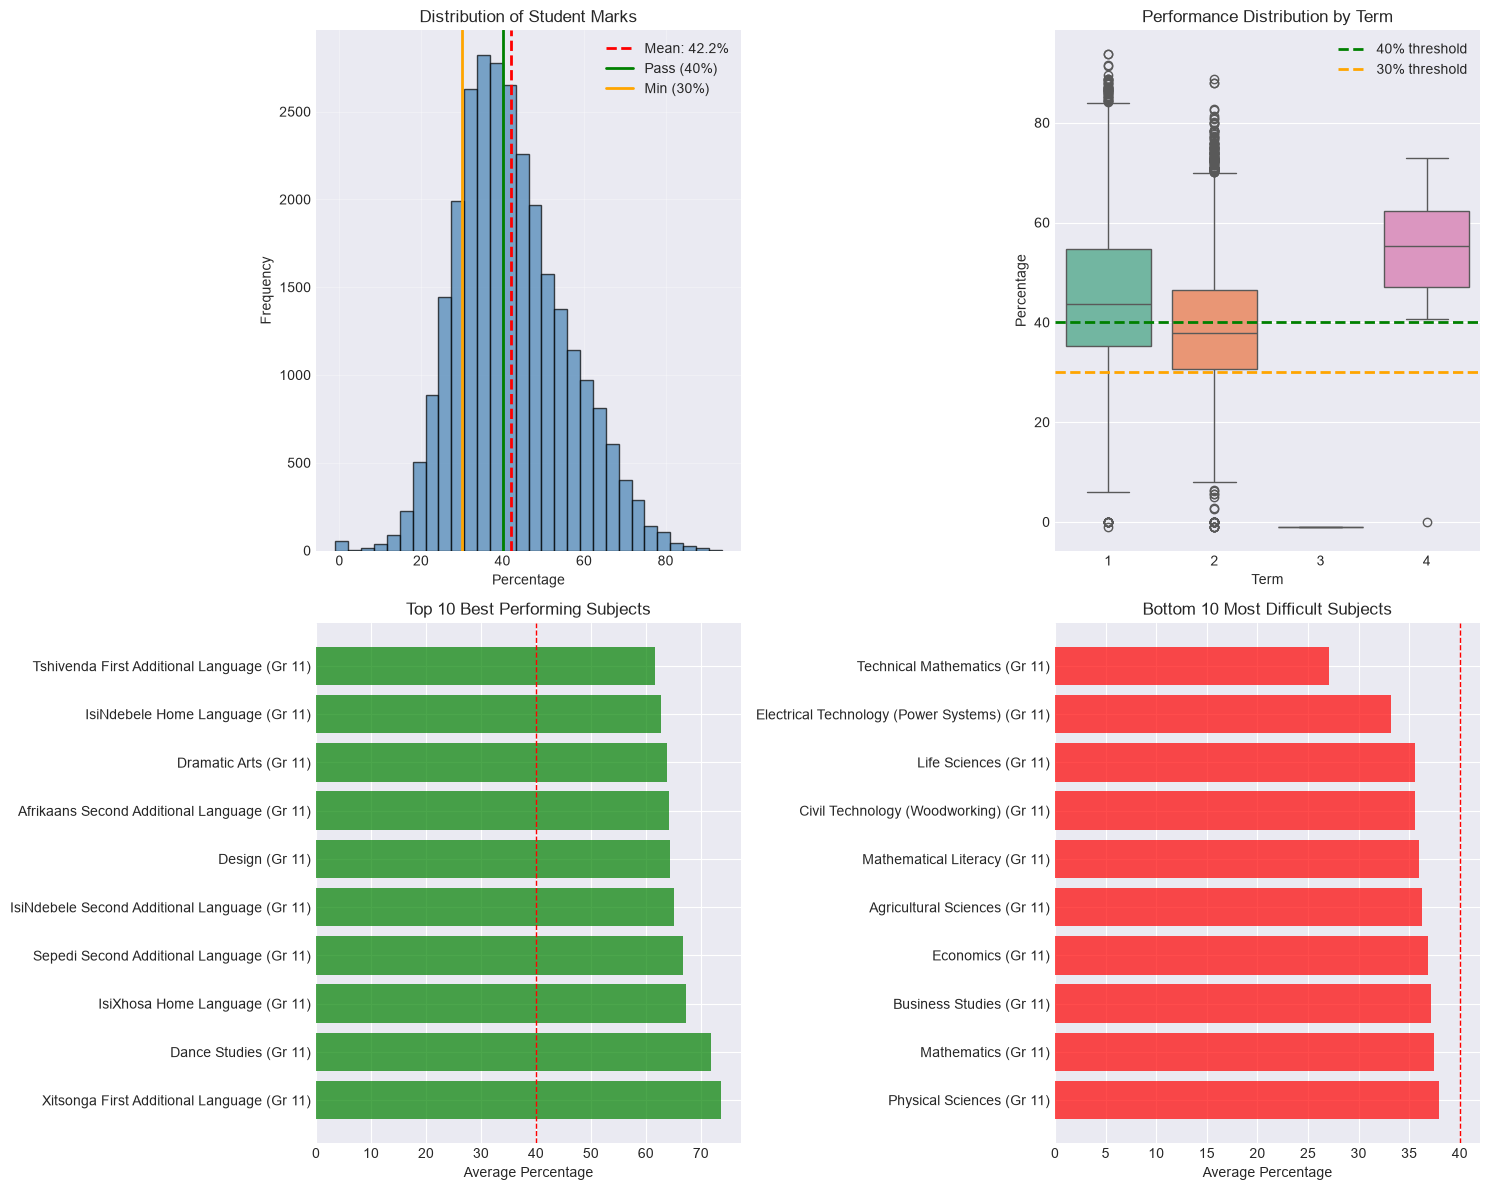

✅ Visualization saved to viz/initial_distribution.png


In [33]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Overall percentage distribution
axes[0, 0].hist(df['Percentage'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['Percentage'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["Percentage"].mean():.1f}%')
axes[0, 0].axvline(40, color='green', linestyle='-', linewidth=2, label='Pass (40%)')
axes[0, 0].axvline(30, color='orange', linestyle='-', linewidth=2, label='Min (30%)')
axes[0, 0].set_xlabel('Percentage')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Student Marks')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Performance by Term (Boxplot)
sns.boxplot(data=df, x='Term', y='Percentage', ax=axes[0, 1], palette='Set2')
axes[0, 1].axhline(40, color='green', linestyle='--', linewidth=2, label='40% threshold')
axes[0, 1].axhline(30, color='orange', linestyle='--', linewidth=2, label='30% threshold')
axes[0, 1].set_title('Performance Distribution by Term')
axes[0, 1].legend()

# 3. Top 10 subjects by average performance
top_subjects = subject_perf.head(10)
axes[1, 0].barh(top_subjects.index, top_subjects['avg_score'], color='green', alpha=0.7)
axes[1, 0].axvline(40, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Average Percentage')
axes[1, 0].set_title('Top 10 Best Performing Subjects')

# 4. Bottom 10 subjects (most difficult)
bottom_subjects = subject_perf.tail(10)
axes[1, 1].barh(bottom_subjects.index, bottom_subjects['avg_score'], color='red', alpha=0.7)
axes[1, 1].axvline(40, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Average Percentage')
axes[1, 1].set_title('Bottom 10 Most Difficult Subjects')

plt.tight_layout()
plt.savefig('../viz/initial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved to viz/initial_distribution.png")